In [6]:
from sklearn.linear_model import Lasso
import numpy as np
from pytorch_lightning import seed_everything
import torch
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from grouping import load_data_with_deciles
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from grouping import load_data_with_deciles

In [7]:
#pip install pytorch-lightning 

In [8]:
np.random.seed(0)

In the Paper they transformed the numerical columns to categorical ones by forming deciles. We implemented two options: 

Option 1: With numerical columns

In [9]:
df = load_data_with_deciles('data/full_pharmaceutical_data.csv', with_numerical_variables = True)
# Define categorical and numerical columns
categorical_cols = ['translated_procedure_types', 'tender_month', 'bidder_city', 'lot_productCode', 'tender_year']
numerical_cols = ['quantity', 'product_bundle_count', 'submission_period_days', 'decision_period_days', 'tender_recordedbidscount', 'supplier_market_share_percent', 'buyer_concentration_percent']

In [10]:
# Preprocessing of columns
preprocessor = ColumnTransformer([
    # Impute categorical with 'NAN', then one-hot encode
    ('cat', 
        Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='NAN')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]),
        categorical_cols
    ),
    # Impute numerical with mean, then scale
    ('num', 
        Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]),
        numerical_cols
    )
])

In [11]:
X = preprocessor.fit_transform(df)
y = df['log_unit_price'].values

In [12]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=0)
# Training data: 70% of original (splits into 59.5% X_train and 10.5 X_val)
# Testing data: 30% of original (X_test)

Lasso Regression

In [13]:
# Calculate lambda_max for Lasso regression
y_centered = y_train - y_train.mean()

if hasattr(X_train, 'T'):  # if sparse matrix
    lam_max = np.abs(X_train.T * y_centered).max()
else:  # if dense matrix
    lam_max = np.abs(X_train.T @ y_centered).max()

In [14]:
# Create a series of 50 values for the regularization parameter 
lam_val = lam_max * np.exp(np.linspace(np.log(1), np.log(1e-4), 50))

In [15]:
# K-fold cross-validation to find the best lambda
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
mae_vals = []

In [16]:
for l in lam_val:
    fold_maes = []
    for train_idx, val_idx in kfold.split(X_train):
        X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        lasso = Lasso(alpha=l, fit_intercept=True, max_iter=10000)
        lasso.fit(X_tr, y_tr)
        val_pred = lasso.predict(X_val_fold)
        fold_maes.append(mean_absolute_error(y_val_fold, val_pred))
    mae_vals.append(np.mean(fold_maes))

In [17]:
best_idx = np.argmin(mae_vals)
best_lambda = lam_val[best_idx]
print(f"Best lambda: {best_lambda:.6f}")
print(f"Best average validation MAE: {mae_vals[best_idx]:.3f}")

Best lambda: 0.012261
Best average validation MAE: 1.236


Plot

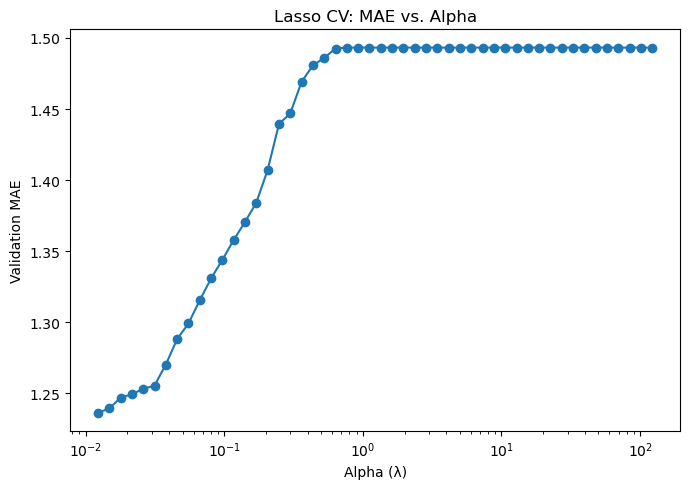

In [18]:
plt.figure(figsize=(7,5))
plt.plot(lam_val, mae_vals, marker='o')
plt.xscale('log')
plt.xlabel('Alpha (λ)')
plt.ylabel('Validation MAE')
plt.title('Lasso CV: MAE vs. Alpha')
plt.tight_layout()
plt.savefig('MAE_vs_Alpha_LR_Opt1', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
# Train model with best lambda
lasso_final = Lasso(alpha=best_lambda, fit_intercept=True)
lasso_final.fit(X_train, y_train)

,alpha,np.float64(0....0932989870047)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


Evaluation

In [20]:
test_pred = lasso_final.predict(X_test)
test_mae = np.mean(np.abs(test_pred - y_test))
test_rmse = np.sqrt(np.mean((test_pred - y_test)**2))
test_r2 = 1 - np.sum((y_test - test_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"Lasso Test MAE: {test_mae:.3f}")
print(f"Lasso Test RMSE: {test_rmse:.3f}")
print(f"Lasso Test R²: {test_r2:.3f}")

Lasso Test MAE: 1.284
Lasso Test RMSE: 1.810
Lasso Test R²: 0.180


Option 2: Without numerical columns (only categorical ones)

In [21]:
df = load_data_with_deciles('data/full_pharmaceutical_data.csv', with_numerical_variables = False)
# Define categorical
categorical_cols = ['quantity_decile', 'product_bundling_decile', 'translated_procedure_types', 'submission_period_group', 'decision_speed_decile', 'tender_month', 'bidders_decile', 'supplier_market_share_decile', 'buyer_concentration_decile', 'bidder_city', 'lot_productCode', 'tender_year']

In [22]:
# Preprocessing of columns
preprocessor = ColumnTransformer([
    # Impute categorical with 'NAN', then one-hot encode
    ('cat', 
        Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='NAN')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]),
        categorical_cols
    )
])

In [23]:
X = preprocessor.fit_transform(df)
y = df['log_unit_price'].values

In [24]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=0)
# Training data: 70% of original (splits into 59.5% X_train and 10.5 X_val)
# Testing data: 30% of original (X_test)

In [25]:
# Calculate lambda_max for Lasso regression
y_centered = y_train - y_train.mean()

if hasattr(X_train, 'T'):  # if sparse matrix
    lam_max = np.abs(X_train.T * y_centered).max()
else:  # if dense matrix
    lam_max = np.abs(X_train.T @ y_centered).max()

In [26]:
# Create a series of 50 values for the regularization parameter 
lam_val = lam_max * np.exp(np.linspace(np.log(1), np.log(1e-4), 50))

In [27]:
# K-fold cross-validation to find the best lambda
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
mae_vals = []

In [28]:
for l in lam_val:
    fold_maes = []
    for train_idx, val_idx in kfold.split(X_train):
        X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        lasso = Lasso(alpha=l, fit_intercept=True, max_iter=10000)
        lasso.fit(X_tr, y_tr)
        val_pred = lasso.predict(X_val_fold)
        fold_maes.append(mean_absolute_error(y_val_fold, val_pred))
    mae_vals.append(np.mean(fold_maes))

In [29]:
best_idx = np.argmin(mae_vals)
best_lambda = lam_val[best_idx]
print(f"Best lambda: {best_lambda:.6f}")
print(f"Best average validation MAE: {mae_vals[best_idx]:.3f}")

Best lambda: 0.012079
Best average validation MAE: 1.146


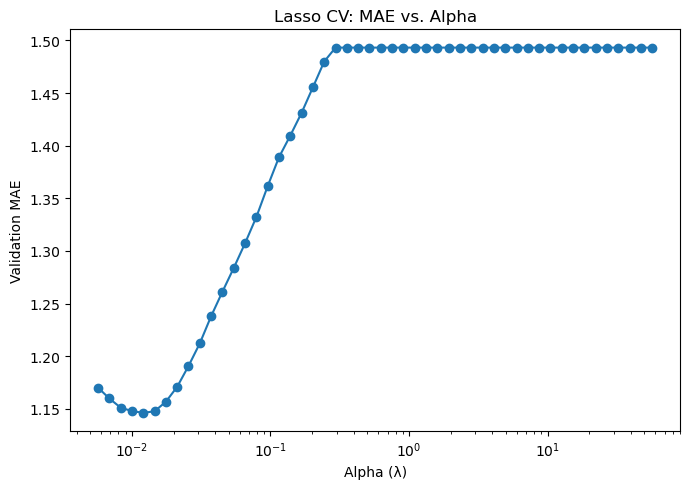

In [30]:
plt.figure(figsize=(7,5))
plt.plot(lam_val, mae_vals, marker='o')
plt.xscale('log')
plt.xlabel('Alpha (λ)')
plt.ylabel('Validation MAE')
plt.title('Lasso CV: MAE vs. Alpha')
plt.tight_layout()
plt.savefig('MAE_vs_Alpha_LR_Opt2', bbox_inches='tight', dpi=150)
plt.show()

In [31]:
# Train model with best lambda
lasso_final = Lasso(alpha=best_lambda, fit_intercept=True)
lasso_final.fit(X_train, y_train)

,alpha,np.float64(0....9034372055427)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [32]:
test_pred = lasso_final.predict(X_test)
test_mae = np.mean(np.abs(test_pred - y_test))
test_rmse = np.sqrt(np.mean((test_pred - y_test)**2))
test_r2 = 1 - np.sum((y_test - test_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"Lasso Test MAE: {test_mae:.3f}")
print(f"Lasso Test RMSE: {test_rmse:.3f}")
print(f"Lasso Test R²: {test_r2:.3f}")

Lasso Test MAE: 1.286
Lasso Test RMSE: 1.855
Lasso Test R²: 0.139
